In [1]:
using Plots
using Optim
using Distributed
using DataFrames
using Dates
using Random
using CSV
using LinearAlgebra
# @everywhere module LPPLS

In [2]:
fname = "/media/mu6mula/Data/Quant/pk-crypto-tools/lppls-master/lppls/data/nasdaq_dotcom.csv"
data = DataFrame(CSV.File(fname))

Row,Date,Open,High,Low,Close,Adj Close,Volume
,Date,Float64,Float64,Float64,Float64,Float64,Int64
1,1994-01-03,774.11,777.29,768.41,770.76,770.76,253020000
2,1994-01-04,771.43,774.78,771.02,774.28,774.28,298600000
3,1994-01-05,775.23,778.21,773.69,778.05,778.05,349880000
4,1994-01-06,780.36,781.21,778.25,780.41,780.41,349210000
5,1994-01-07,779.29,783.39,778.2,782.94,782.94,330060000
6,1994-01-10,783.05,787.49,782.92,786.69,786.69,313350000
7,1994-01-11,785.93,787.32,784.34,785.52,785.52,321930000
8,1994-01-12,788.2,788.43,782.68,786.87,786.87,322540000
9,1994-01-13,784.36,787.85,783.97,787.81,787.81,290110000


In [50]:

mutable struct LPPLSModel
    tord::Array{Float64,1}
    price::Array{Float64,1}
    # coef::Dict{Symbol, Float64}
    # indicator_result::Array{Any, 1}
end

# function LPPLSModel(tord::Array{Float64,1}, price::Array{Float64,1})
#     LPPLSModel(tord,price, Dict{Symbol, Float64}(), [])
# end


function fitABC(T,P, tc, m, w)
    # T = model.tord
    # P = model.price
    N = length(T)

    dT = abs.(tc .- T) .+ 1e-8
    phase = log.(dT)

    fi = dT.^m
    gi = fi .* cos.(w .* phase)
    hi = fi .* sin.(w .* phase)

    fi_pow_2 = fi.^2
    gi_pow_2 = gi.^2
    hi_pow_2 = hi.^2

    figi = fi .* gi
    fihi = fi .* hi
    gihi = gi .* hi

    yi = P
    yifi = yi .* fi
    yigi = yi .* gi
    yihi = yi .* hi

    matrix_1 = [
        N sum(fi) sum(gi) sum(hi);
        sum(fi) sum(fi_pow_2) sum(figi) sum(fihi);
        sum(gi) sum(figi) sum(gi_pow_2) sum(gihi);
        sum(hi) sum(fihi) sum(gihi) sum(hi_pow_2)
    ]

    matrix_2 = [
        sum(yi);
        sum(yifi);
        sum(yigi);
        sum(yihi)
    ]

    matrix_1 += 1e-8 * I(4)
    return matrix_1 \ matrix_2
end


function plot_fit(model::LPPLSModel, coef)
    tc, m, w, a, b, c, c1, c2 = coef
    # tc, m, w, a, b, c, c1, c2 = values(model.coef)
    # time_ord = [Dates.Date(Dates.UTM(1970, 1, 1) + Dates.Day(d)) for d in model.observations[1, :]]
    # time_ord = t_obs = model.observations[:,1]
    # lppls_fit = [lppls(t, tc, m, w, a, b, c1, c2) for t in t_obs]
    lppls_fit = lppls(tord, tc, m, w, a, b, c1, c2) 
    price = model.price

    # first = t_obs[1]
    # last = t_obs[end]

    # O = (w / (2.0 * π)) * log((tc - first) / (tc - last))
    # D = (m * abs(b)) / (w * abs(c))

    plot(model.price, size = (1200,400))
    plot!(lppls_fit)
    # plot(time_ord, price, label="price", color="black", linewidth=0.75)
    # plot!(time_ord, lppls_fit, label="lppls fit", color="blue", alpha=0.5)
    # grid!(:both)
    # ylabel!("ln(p)")
    # legend!(:topright)
end


plot_fit (generic function with 1 method)

In [53]:

function func_restricted(model::LPPLSModel, x)
    tc, m, w = x
    rM = matrix_equation(model, tc, m, w)
    # print("func_restricted rM", rM)
    a, b, c1, c2 = rM[:, 1]
    # println("func_restricted a, b, c1, c2 = ", [a, b, c1, c2])
    delta = lppls(model.tord, tc, m, w, a, b, c1, c2)
    # println("\nfunc_restricted lppls ", (delta))
    # println("\nfunc_restricted lppls ", sum(delta))
    delta = delta .- model.price
    # println("\nfunc_restricted delta ", (delta))
    # println("\nfunc_restricted delta ", sum(delta))
    return sum(delta .^2)
end


function estimate_params(model::LPPLSModel, seed, minimizer)
    result = optimize(x -> func_restricted(model, x), seed, minimizer)
    # print(result)
    if Optim.converged(result)
        tc, m, w = Optim.minimizer(result)
        rM = matrix_equation(model, tc, m, w)
        a, b, c1, c2 = rM[:, 1]
        c = sqrt(c1^2 + c2^2)
        # model.coef = Dict(:tc => tc, :m => m, :w => w, :a => a, :b => b, :c => c, :c1 => c1, :c2 => c2)
        return tc, m, w, a, b, c, c1, c2
    else
        throw(ArgumentError("Optimization failed"))
    end
end

function lppls(t, tc, m, w, a, b, c1, c2)
    # println("lppls t: ", t)
    dt = abs.(tc .- t) .+ 1e-8
    wphase = w .* log.(dt)
    return a .+ dt.^m .* (b .+ (c1 .* cos.(wphase) + c2 * sin.(wphase)))
end



function fit(model::LPPLSModel, max_searches, minimizer=NelderMead())
    # obs = obs === nothing ? model.observations : obs
    # obs = model.observations
    search_count = 0

    while search_count < max_searches
        t1 = model.tord[1]
        t2 = model.tord[end]
        init_limits = [
            (t2 - 0.2 * (t2 - t1), t2 + 0.2 * (t2 - t1)),
            (0.1, 1.0),
            (6.0, 13.0)
        ]

        non_lin_vals = [rand(a[1]:a[2]) for a in init_limits]
        tc, m, w = non_lin_vals
        seed = [tc, m, w]
        # println("fit seed= ", seed)

        try
            return estimate_params(model, seed, minimizer)
        catch
            search_count += 1
        end
    end
    return 0, 0, 0, 0, 0, 0, 0, 0
end


fit (generic function with 2 methods)

In [205]:

P = log.(data."Adj Close")
T = Float64.(collect(1:size(price)[1]))
minimizer = NelderMead()

# model = LPPLSModel(tord, price)

###########################


t1 = T[1]
t2 = T[end]
init_limits = [
    (t2 - 0.2 * (t2 - t1), t2 + 0.2 * (t2 - t1)),
    (0.1, 0.9),
    (6.0, 13.0)
]

tc0, m0, w0  = [a[1]+(a[2]-a[1])*rand() for a in init_limits]

fitABC(T,P,tc0, m0, w0)

4-element Vector{Float64}:
  8.38698968286476
 -0.007466368452723815
 -5.231981900532555e-5
  7.0246447055857406e-6

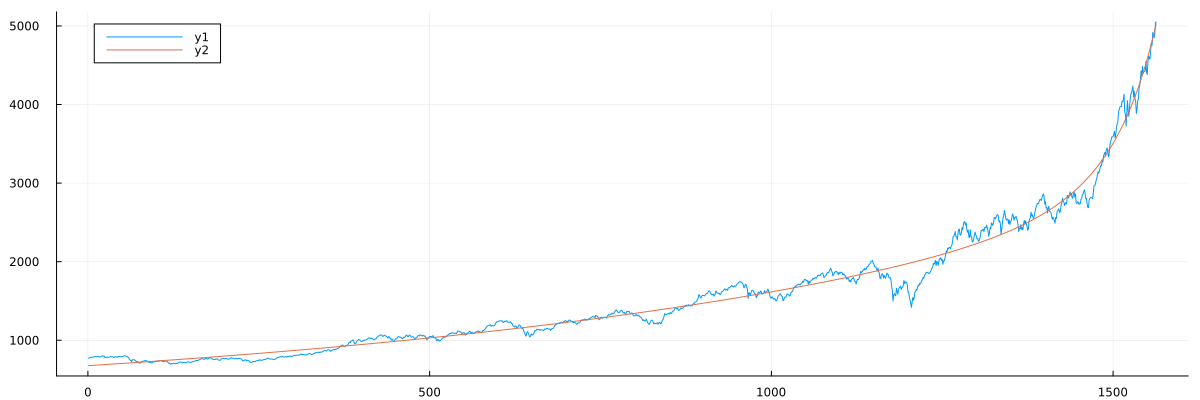

In [163]:

price = (data."Adj Close")
tord = Float64.(collect(1:size(price)[1]))
minimizer = NelderMead()

model = LPPLSModel(tord, price)

MAX_SEARCHES = 25
coef = fit(model, MAX_SEARCHES)
plot_fit(model, coef)




In [ ]:
Financial “anti-bubbles”: Log-periodicity in Gold and Nikkei collapses

In [33]:
seed= [1344.6, 0.1, 6.0]
estimate_params(model, seed, minimizer)

(2540.8910386594034, -1.1591983187340755, 7.441346901267462, 5.685502458089, 8211.36564601827, 541.0635953893998, 353.9598379928247, -409.2215137841576)

In [ ]:


# Convert date strings to ordinal dates and adjust closing prices to logarithms
# time = [Dates.Date(Dates.parse(string(t1), "yyyy-mm-dd")) for t1 in data.Date]
# ordinal_time = Dates.value.(data.Date) #[Dates.value(t) for t in time]



# Prepare observations
# obs = observations = hcat(ordinal_time, price)

# t1 = t[1]
# t2 = t[end]
# init_limits = [
#     (t2 - 0.2 * (t2 - t1), t2 + 0.2 * (t2 - t1)),
#     (0.1, 1.0),
#     (6.0, 13.0)
# ]

# non_lin_vals = [rand(a[1]:a[2]) for a in init_limits]
# tc, m, w = non_lin_vals
# seed = [tc, m, w]
# seed

# # Maximum number of searches as suggested by literature
# MAX_SEARCHES = 25

# # Create an instance of LPPLSModel
# model = LPPLSModel(observations)

# # Fit the model to the data and get back the parameters
# tc, m, w, a, b, c, c1, c2 = fit(model, MAX_SEARCHES)

# println("tc: $tc, m: $m, w: $w, a: $a, b: $b, c: $c, c1: $c1, c2: $c2")

# # Visualize the fit
# plot_fit(lppls_model)

#################

# tc, m, w, a, b, c, c1, c2 = values(model.coef)
# # time_ord = [Dates.Date(Dates.UTM(1970, 1, 1) + Dates.Day(d)) for d in model.observations[1, :]]
# # time_ord = model.observations[:,1]
# time_ord = t_obs = model.observations[:,1]
# lppls_fit = [lppls(t, tc, m, w, a, b, c1, c2) for t in t_obs]
# price = model.observations[:,2]

# first = t_obs[1]
# last = t_obs[end]

# O = (w / (2.0 * π)) * log((tc - first) / (tc - last))
# D = (m * abs(b)) / (w * abs(c))
# plot(price)
# plot(lppls_fit)
# plot(time_ord, price, label="price", color="black", linewidth=0.75)
# plot!(time_ord, lppls_fit, label="lppls fit", color="blue", alpha=0.5)
# grid!(:both)
# ylabel!("ln(p)")
# legend!(:topright)

In [ ]:
# model.observations[:,2]
# price
# lppls_fit

In [ ]:
# plot(price)

In [ ]:



# function compute_indicators(model::LPPLSModel, res, filter_conditions_config=nothing)
#     pos_lst = []
#     neg_lst = []
#     pos_conf_lst = []
#     neg_conf_lst = []
#     price = []
#     ts = []
#     _fits = []

#     m_min, m_max = (0.0, 1.0)
#     w_min, w_max = (2.0, 15.0)
#     O_min = 2.5
#     D_min = 0.5

#     for r in res
#         push!(ts, r["t2"])
#         push!(price, r["p2"])
#         pos_qual_count = 0
#         neg_qual_count = 0
#         pos_count = 0
#         neg_count = 0

#         for fits in r["res"]
#             t1, t2, tc, m, w, b, c, O, D = fits["t1"], fits["t2"], fits["tc"], fits["m"], fits["w"], fits["b"], fits["c"], fits["O"], fits["D"]

#             tc_in_range = (max(t2 - 60, t2 - 0.5 * (t2 - t1)) < tc < min(t2 + 252, t2 + 0.5 * (t2 - t1)))
#             m_in_range = m_min < m < m_max
#             w_in_range = w_min < w < w_max

#             if b != 0 && c != 0
#                 O = O
#             else
#                 O = Inf
#             end

#             O_in_range = O > O_min
#             D_in_range = D > D_min

#             is_qualified = tc_in_range && m_in_range && w_in_range && O_in_range && D_in_range

#             if b < 0
#                 pos_count += 1
#                 if is_qualified
#                     pos_qual_count += 1
#                 end
#             end
#             if b > 0
#                 neg_count += 1
#                 if is_qualified
#                     neg_qual_count += 1
#                 end
#             end
#             fits["is_qualified"] = is_qualified
#         end

#         push!(_fits, r["res"])
#         pos_conf = pos_qual_count / pos_count > 0 ? pos_count : 0
#         neg_conf = neg_qual_count / neg_count > 0 ? neg_count : 0
#         push!(pos_conf_lst, pos_conf)
#         push!(neg_conf_lst, neg_conf)
#     end

#     res_df = DataFrame(time=ts, price=price, pos_conf=pos_conf_lst, neg_conf=neg_conf_lst, _fits=_fits)
#     return res_df
# end

# function plot_confidence_indicators(model::LPPLSModel, res)
#     res_df = compute_indicators(model, res)
#     time_ord = res_df.time
#     ts = [Dates.Date(Dates.UTM(1970, 1, 1) + Dates.Day(d)) for d in time_ord]

#     plot(ts, res_df.price, label="price", color="black", linewidth=0.75
